# 08 GenAI RAG Evaluation

This notebook evaluates the inventory RAG retrieval layer.

The evaluation uses business queries and checks whether the retrieved inventory documents contain expected relevant signals.

In [0]:
spark.sql("USE CATALOG workspace")
spark.sql("USE SCHEMA retail_capstone")

spark.sql("SELECT current_catalog(), current_schema()").show()

+-----------------+----------------+
|current_catalog()|current_schema()|
+-----------------+----------------+
|        workspace| retail_capstone|
+-----------------+----------------+



In [0]:
import pandas as pd
import numpy as np

from pyspark.sql.functions import col, lower, lit, when, round

In [0]:
rag_df = spark.table("workspace.retail_capstone.inventory_rag_documents")

display(
    rag_df.select(
        "document_id",
        "stock_code",
        "product_name",
        "stockout_risk_level",
        "reorder_flag",
        "business_priority_score",
        "rag_document_text"
    )
)

document_id,stock_code,product_name,stockout_risk_level,reorder_flag,business_priority_score,rag_document_text
84029G_WH002,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,High Risk,Reorder Needed,0.909,"Product 84029G, KNITTED UNION FLAG HOT WATER BOTTLE, belongs to category Home & Living and brand WarmHome. It is stored in warehouse WH002 named Berlin Distribution Hub. Available stock is 25 units. Current stock is 35 units. Average daily sales is 17.91 units. Days of inventory remaining is 1.4. Supplier is WarmHome Manufacturing with lead time of 14 days and reliability score of 0.91. Stockout risk level is High Risk. Reorder status is Reorder Needed. Recommended reorder quantity is 120 units. Inventory value is 122.5."
85123A_WH001,85123A,WHITE HANGING HEART T-LIGHT HOLDER,High Risk,No Reorder Needed,0.606,"Product 85123A, WHITE HANGING HEART T-LIGHT HOLDER, belongs to category Home Decor and brand Generic Home. It is stored in warehouse WH001 named Nuremberg Fulfillment Center. Available stock is 210 units. Current stock is 250 units. Average daily sales is 120.15 units. Days of inventory remaining is 1.75. Supplier is Global Home Supplies with lead time of 7 days and reliability score of 0.94. Stockout risk level is High Risk. Reorder status is No Reorder Needed. Recommended reorder quantity is 0 units. Inventory value is 312.5."
84029E_WH002,84029E,RED WOOLLY HOTTIE WHITE HEART,High Risk,Reorder Needed,0.909,"Product 84029E, RED WOOLLY HOTTIE WHITE HEART, belongs to category Home & Living and brand WarmHome. It is stored in warehouse WH002 named Berlin Distribution Hub. Available stock is 48 units. Current stock is 60 units. Average daily sales is 38.24 units. Days of inventory remaining is 1.26. Supplier is WarmHome Manufacturing with lead time of 14 days and reliability score of 0.91. Stockout risk level is High Risk. Reorder status is Reorder Needed. Recommended reorder quantity is 120 units. Inventory value is 195.0."
84879_WH001,84879,ASSORTED COLOUR BIRD ORNAMENT,High Risk,No Reorder Needed,0.606,"Product 84879, ASSORTED COLOUR BIRD ORNAMENT, belongs to category Home Decor and brand Generic Home. It is stored in warehouse WH001 named Nuremberg Fulfillment Center. Available stock is 100 units. Current stock is 110 units. Average daily sales is 117.5 units. Days of inventory remaining is 0.85. Supplier is Global Home Supplies with lead time of 7 days and reliability score of 0.94. Stockout risk level is High Risk. Reorder status is No Reorder Needed. Recommended reorder quantity is 0 units. Inventory value is 165.0."
71053_WH001,71053,WHITE METAL LANTERN,Medium Risk,Reorder Needed,0.756,"Product 71053, WHITE METAL LANTERN, belongs to category Home Decor and brand Generic Home. It is stored in warehouse WH001 named Nuremberg Fulfillment Center. Available stock is 75 units. Current stock is 90 units. Average daily sales is 10.41 units. Days of inventory remaining is 7.2. Supplier is Global Home Supplies with lead time of 7 days and reliability score of 0.94. Stockout risk level is Medium Risk. Reorder status is Reorder Needed. Recommended reorder quantity is 200 units. Inventory value is 189.0."
21730_WH001,21730,GLASS STAR FROSTED T-LIGHT HOLDER,Low Risk,No Reorder Needed,0.251,"Product 21730, GLASS STAR FROSTED T-LIGHT HOLDER, belongs to category Home Decor and brand GlassWorks. It is stored in warehouse WH001 named Nuremberg Fulfillment Center. Available stock is 110 units. Current stock is 140 units. Average daily sales is 6.29 units. Days of inventory remaining is 17.49. Supplier is GlassWorks Studio with lead time of 9 days and reliability score of 0.89. Stockout risk level is Low Risk. Reorder status is No Reorder Needed. Recommended reorder quantity is 0 units. Inventory value is 385.0."
22752_WH003,22752,SET 7 BABUSHKA NESTING BOXES,High Risk,Reorder Needed,0.914,"Product 22752, SET 7 BABUSHKA NESTING BOXES, belongs to category Gifts and brand GiftCraft. It is stored in warehouse WH003 named Cologne Regional Wareho

In [0]:
def retrieve_inventory_context(query: str, top_k: int = 5):
    query_lower = query.lower()

    result_df = rag_df.withColumn(
        "query",
        lit(query_lower)
    ).withColumn(
        "retrieval_score",
        when(lower(col("rag_document_text")).contains(query_lower), 1.0)
        .when(lower(col("stockout_risk_level")).contains(query_lower), 0.9)
        .when(lower(col("reorder_flag")).contains(query_lower), 0.9)
        .when(lower(col("product_name")).contains(query_lower), 0.8)
        .when(lower(col("category")).contains(query_lower), 0.7)
        .when(lower(col("supplier_name")).contains(query_lower), 0.7)
        .otherwise(0.1)
    ).withColumn(
        "final_score",
        round(
            col("retrieval_score") * (lit(0.6) + lit(0.4) * col("business_priority_score")),
            4
        )
    ).orderBy(
        col("final_score").desc(),
        col("business_priority_score").desc()
    )

    return result_df.select(
        "document_id",
        "stock_code",
        "product_name",
        "warehouse_id",
        "stockout_risk_level",
        "reorder_flag",
        "business_priority_score",
        "retrieval_score",
        "final_score",
        "rag_document_text"
    ).limit(top_k)

In [0]:
evaluation_queries = [
    {
        "query": "Which products are high stockout risk?",
        "expected_terms": ["High Risk"]
    },
    {
        "query": "Which products should be reordered?",
        "expected_terms": ["Reorder Needed"]
    },
    {
        "query": "Which products have low available stock?",
        "expected_terms": ["Available stock"]
    },
    {
        "query": "Which suppliers have long lead times?",
        "expected_terms": ["lead time"]
    },
    {
        "query": "Which products have high sales velocity?",
        "expected_terms": ["Average daily sales"]
    },
    {
        "query": "Show products with low stock and high sales velocity",
        "expected_terms": ["Available stock", "Average daily sales"]
    }
]

evaluation_pd = pd.DataFrame(evaluation_queries)
display(evaluation_pd)

query,expected_terms
Which products are high stockout risk?,List(High Risk)
Which products should be reordered?,List(Reorder Needed)
Which products have low available stock?,List(Available stock)
Which suppliers have long lead times?,List(lead time)
Which products have high sales velocity?,List(Average daily sales)
Show products with low stock and high sales velocity,"List(Available stock, Average daily sales)"


In [0]:
def is_relevant(document_text: str, expected_terms: list) -> int:
    text_lower = document_text.lower()

    for term in expected_terms:
        if term.lower() in text_lower:
            return 1

    return 0

In [0]:
def precision_at_k(relevance_list, k):
    top_k = relevance_list[:k]
    if k == 0:
        return 0.0
    return sum(top_k) / k


def recall_at_k(relevance_list, total_relevant, k):
    if total_relevant == 0:
        return 0.0
    top_k = relevance_list[:k]
    return sum(top_k) / total_relevant


def reciprocal_rank(relevance_list):
    for idx, rel in enumerate(relevance_list):
        if rel == 1:
            return 1 / (idx + 1)
    return 0.0


def dcg_at_k(relevance_list, k):
    score = 0.0
    for idx, rel in enumerate(relevance_list[:k]):
        score += rel / np.log2(idx + 2)
    return score


def ndcg_at_k(relevance_list, k):
    dcg = dcg_at_k(relevance_list, k)
    ideal_relevance = sorted(relevance_list, reverse=True)
    idcg = dcg_at_k(ideal_relevance, k)

    if idcg == 0:
        return 0.0

    return dcg / idcg

In [0]:
evaluation_results = []

for item in evaluation_queries:
    query = item["query"]
    expected_terms = item["expected_terms"]

    retrieved_pd = retrieve_inventory_context(query, top_k=5).toPandas()

    relevance_list = [
        is_relevant(text, expected_terms)
        for text in retrieved_pd["rag_document_text"].tolist()
    ]

    total_relevant = max(sum(relevance_list), 1)

    result = {
        "query": query,
        "expected_terms": ", ".join(expected_terms),
        "mrr": reciprocal_rank(relevance_list),
        "precision_at_1": precision_at_k(relevance_list, 1),
        "precision_at_3": precision_at_k(relevance_list, 3),
        "precision_at_5": precision_at_k(relevance_list, 5),
        "recall_at_3": recall_at_k(relevance_list, total_relevant, 3),
        "recall_at_5": recall_at_k(relevance_list, total_relevant, 5),
        "ndcg_at_3": ndcg_at_k(relevance_list, 3),
        "ndcg_at_5": ndcg_at_k(relevance_list, 5)
    }

    evaluation_results.append(result)

evaluation_results_pd = pd.DataFrame(evaluation_results)

display(evaluation_results_pd)

query,expected_terms,mrr,precision_at_1,precision_at_3,precision_at_5,recall_at_3,recall_at_5,ndcg_at_3,ndcg_at_5
Which products are high stockout risk?,High Risk,1.0,1.0,1.0,1.0,0.6,1.0,1.0,1.0
Which products should be reordered?,Reorder Needed,1.0,1.0,1.0,1.0,0.6,1.0,1.0,1.0
Which products have low available stock?,Available stock,1.0,1.0,1.0,1.0,0.6,1.0,1.0,1.0
Which suppliers have long lead times?,lead time,1.0,1.0,1.0,1.0,0.6,1.0,1.0,1.0
Which products have high sales velocity?,Average daily sales,1.0,1.0,1.0,1.0,0.6,1.0,1.0,1.0
Show products with low stock and high sales velocity,"Available stock, Average daily sales",1.0,1.0,1.0,1.0,0.6,1.0,1.0,1.0


In [0]:
summary_metrics = evaluation_results_pd[[
    "mrr",
    "precision_at_1",
    "precision_at_3",
    "precision_at_5",
    "recall_at_3",
    "recall_at_5",
    "ndcg_at_3",
    "ndcg_at_5"
]].mean().reset_index()

summary_metrics.columns = ["metric", "average_value"]

display(summary_metrics)

metric,average_value
mrr,1.0
precision_at_1,1.0
precision_at_3,1.0
precision_at_5,1.0
recall_at_3,0.6
recall_at_5,1.0
ndcg_at_3,1.0
ndcg_at_5,1.0


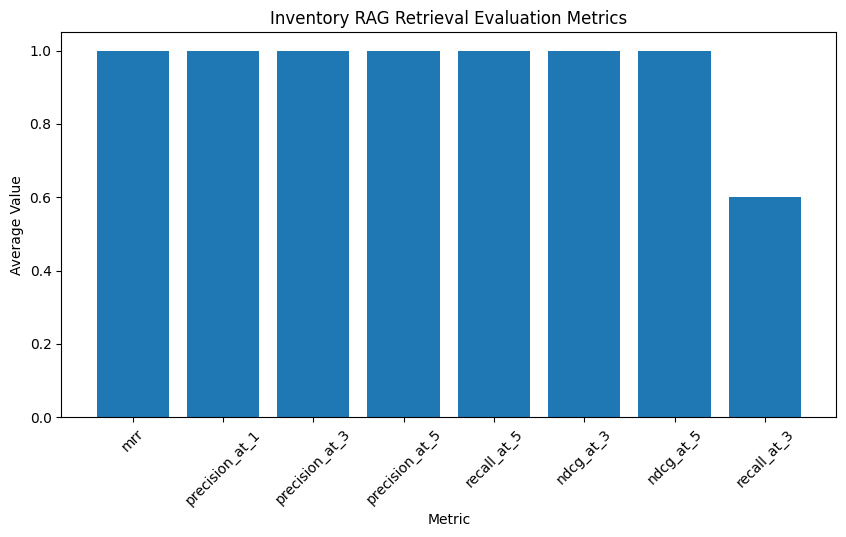

In [0]:
plt_df = summary_metrics.sort_values("average_value", ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(plt_df["metric"], plt_df["average_value"])
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.title("Inventory RAG Retrieval Evaluation Metrics")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.show()

In [0]:
sample_query = "Which products should be reordered?"

display(
    retrieve_inventory_context(sample_query, top_k=5)
)

document_id,stock_code,product_name,warehouse_id,stockout_risk_level,reorder_flag,business_priority_score,retrieval_score,final_score,rag_document_text
22752_WH003,22752,SET 7 BABUSHKA NESTING BOXES,WH003,High Risk,Reorder Needed,0.914,0.1,0.0966,"Product 22752, SET 7 BABUSHKA NESTING BOXES, belongs to category Gifts and brand GiftCraft. It is stored in warehouse WH003 named Cologne Regional Warehouse. Available stock is 20 units. Current stock is 25 units. Average daily sales is 9.2 units. Days of inventory remaining is 2.17. Supplier is GiftCraft Wholesale with lead time of 12 days and reliability score of 0.86. Stockout risk level is High Risk. Reorder status is Reorder Needed. Recommended reorder quantity is 100 units. Inventory value is 100.0."
84406B_WH002,84406B,CREAM CUPID HEARTS COAT HANGER,WH002,High Risk,Reorder Needed,0.912,0.1,0.0965,"Product 84406B, CREAM CUPID HEARTS COAT HANGER, belongs to category Home Decor and brand Generic Home. It is stored in warehouse WH002 named Berlin Distribution Hub. Available stock is 40 units. Current stock is 45 units. Average daily sales is 12.52 units. Days of inventory remaining is 3.19. Supplier is DecorCraft Europe with lead time of 10 days and reliability score of 0.88. Stockout risk level is High Risk. Reorder status is Reorder Needed. Recommended reorder quantity is 150 units. Inventory value is 83.25."
84029E_WH002,84029E,RED WOOLLY HOTTIE WHITE HEART,WH002,High Risk,Reorder Needed,0.909,0.1,0.0964,"Product 84029E, RED WOOLLY HOTTIE WHITE HEART, belongs to category Home & Living and brand WarmHome. It is stored in warehouse WH002 named Berlin Distribution Hub. Available stock is 48 units. Current stock is 60 units. Average daily sales is 38.24 units. Days of inventory remaining is 1.26. Supplier is WarmHome Manufacturing with lead time of 14 days and reliability score of 0.91. Stockout risk level is High Risk. Reorder status is Reorder Needed. Recommended reorder quantity is 120 units. Inventory value is 195.0."
84029G_WH002,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,WH002,High Risk,Reorder Needed,0.909,0.1,0.0964,"Product 84029G, KNITTED UNION FLAG HOT WATER BOTTLE, belongs to category Home & Living and brand WarmHome. It is stored in warehouse WH002 named Berlin Distribution Hub. Available stock is 25 units. Current stock is 35 units. Average daily sales is 17.91 units. Days of inventory remaining is 1.4. Supplier is WarmHome Manufacturing with lead time of 14 days and reliability score of 0.91. Stockout risk level is High Risk. Reorder status is Reorder Needed. Recommended reorder quantity is 120 units. Inventory value is 122.5."
22633_WH003,22633,HAND WARMER UNION JACK,WH003,High Risk,Reorder Needed,0.909,0.1,0.0964,"Product 22633, HAND WARMER UNION JACK, belongs to category Accessories and brand WarmHome. It is stored in warehouse WH003 named Cologne Regional Warehouse. Available stock is 60 units. Current stock is 80 units. Average daily sales is 45.52 units. Days of inventory remaining is 1.32. Supplier is WarmHome Manufacturing with lead time of 14 days and reliability score of 0.91. Stockout risk level is High Risk. Reorder status is Reorder Needed. Recommended reorder quantity is 300 units. Inventory value is 88.0."


# RAG Evaluation Summary

This notebook evaluates the inventory retrieval layer using a small set of business queries.

The evaluation uses term-matching relevance. A retrieved document is considered relevant if it contains the expected business signal, such as `High Risk` or `Reorder Needed`.

Metrics calculated:

- MRR
- Precision@1
- Precision@3
- Precision@5
- Recall@3
- Recall@5
- NDCG@3
- NDCG@5

This is a simple v1 evaluation approach. A stronger future version would use LLM-judged relevance and a larger evaluation dataset.